In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shree0910/india-tech-job-market-2026-23k-records/indian_tech_jobs_2026.csv


## Section 1 — Setup & Data Loading

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

PALETTE = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#44BBA4',
           '#393E41','#E94F37','#7B68EE','#F5A623','#5C6BC0']
sns.set_palette(PALETTE)

### 1.1 : Load dataset

In [3]:
job_dataset = pd.read_csv('/kaggle/input/datasets/shree0910/india-tech-job-market-2026-23k-records/indian_tech_jobs_2026.csv')
job_dataset.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [4]:
job_dataset.columns.tolist()

['job_id',
 'job_title',
 'company_name',
 'company_rating',
 'location',
 'scraped_city',
 'role_category',
 'experience_raw',
 'experience_min_yrs',
 'experience_max_yrs',
 'salary_raw',
 'salary_min_lpa',
 'salary_max_lpa',
 'salary_disclosed',
 'skills_required',
 'skills_count',
 'job_description',
 'posted_date_raw',
 'work_mode',
 'company_size_bucket',
 'job_url',
 'data_source',
 'scraped_at',
 'salary_tier',
 'experience_tier',
 'is_senior',
 'primary_city',
 'skill_domain',
 'salary_midpoint_lpa',
 'days_since_posted',
 'is_fresher_friendly',
 'salary_negotiable']

In [5]:
job_dataset.describe().round(2)

,job_id,company_rating,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,skills_count,salary_midpoint_lpa,days_since_posted
count,23201.0,23201.00,23201.00,23201.00,23201.00,23201.00,23201.00,23201.00,23201.00
mean,11601.0,3.59,4.14,7.83,1.38,2.27,7.60,1.83,15.70
std,6697.7,0.51,2.93,3.95,4.84,7.47,1.46,6.11,7.58
min,1.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,5801.0,3.40,2.00,5.00,0.00,0.00,8.00,0.00,7.00
50%,11601.0,3.60,4.00,8.00,0.00,0.00,8.00,0.00,21.00
75%,17401.0,3.80,6.00,10.00,0.00,0.00,8.00,0.00,21.00
max,23201.0,5.00,25.00,31.00,85.00,90.00,8.00,87.50,90.00


In [6]:
print(job_dataset.dtypes.to_string())

job_id                   int64
job_title               object
company_name            object
company_rating         float64
location                object
scraped_city            object
role_category           object
experience_raw          object
experience_min_yrs     float64
experience_max_yrs     float64
salary_raw              object
salary_min_lpa         float64
salary_max_lpa         float64
salary_disclosed          bool
skills_required         object
skills_count             int64
job_description         object
posted_date_raw         object
work_mode               object
company_size_bucket     object
job_url                 object
data_source             object
scraped_at              object
salary_tier             object
experience_tier         object
is_senior                 bool
primary_city            object
skill_domain            object
salary_midpoint_lpa    float64
days_since_posted      float64
is_fresher_friendly       bool
salary_negotiable         bool


In [7]:
job_dataset.isnull().sum()

job_id                  0
job_title               0
company_name            0
company_rating          0
location                0
scraped_city            0
role_category           0
experience_raw          0
experience_min_yrs      0
experience_max_yrs      0
salary_raw              0
salary_min_lpa          0
salary_max_lpa          0
salary_disclosed        0
skills_required         0
skills_count            0
job_description         0
posted_date_raw         0
work_mode               0
company_size_bucket     0
job_url                53
data_source             0
scraped_at              0
salary_tier             0
experience_tier         0
is_senior               0
primary_city            0
skill_domain            0
salary_midpoint_lpa     0
days_since_posted       0
is_fresher_friendly     0
salary_negotiable       0
dtype: int64

## Section 2 — Exploratory Data Analysis (EDA)

### 2.1 — Job Role Distribution

In [8]:
roles_count = job_dataset['role_category'].value_counts()
print(roles_count)

print(roles_count.index[::-1])
print(roles_count.values[::-1])

role_category
Data Scientist               6455
Data Analyst                 4729
Business Analyst             4505
Machine Learning Engineer    4004
Data Engineer                1922
Python Developer             1586
Name: count, dtype: int64
Index(['Python Developer', 'Data Engineer', 'Machine Learning Engineer',
       'Business Analyst', 'Data Analyst', 'Data Scientist'],
      dtype='object', name='role_category')
[1586 1922 4004 4505 4729 6455]


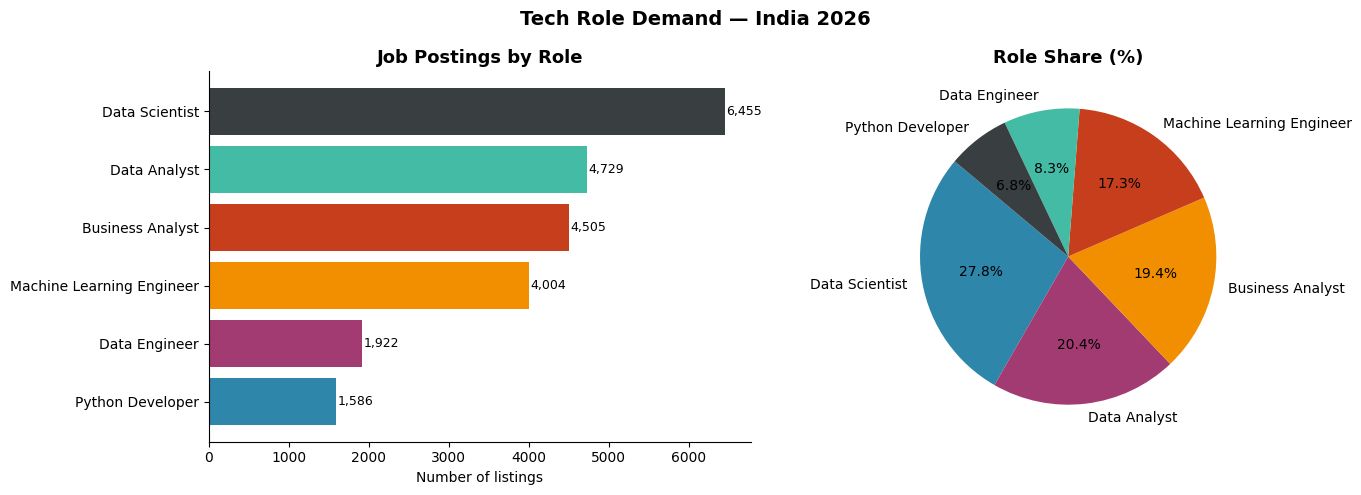

In [9]:
fig, axes = plt.subplots(1,2 , figsize=(14,5))

axes[0].barh(roles_count.index[::-1], roles_count.values[::-1], color=PALETTE[:6])

axes[0].set_title('Job Postings by Role', fontsize=13,fontweight='bold')
axes[0].set_xlabel('Number of listings')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, v in enumerate(roles_count.values[::-1]):
    axes[0].text(v + 20, i, f'{v:,}', va='center', fontsize=9)

axes[1].pie(roles_count.values, labels=roles_count.index,autopct='%1.1f%%', 
            colors=PALETTE[:6], startangle=140)
axes[1].set_title('Role Share (%)', fontsize=13, fontweight='bold')

plt.suptitle('Tech Role Demand — India 2026', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_role_distribution.png', bbox_inches='tight')
plt.show()

Insight: Data Scientist dominates with 27.8%, followed by Data Analyst (20.4%).

### 2.2 — City-wise Distribution

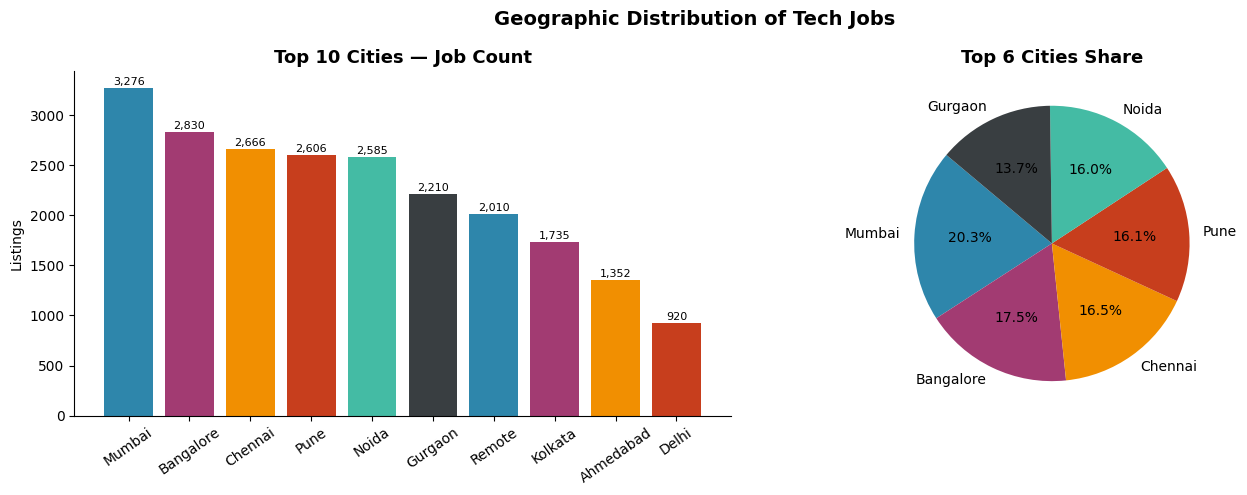

In [10]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

city_counts = job_dataset['primary_city'].value_counts().head(10)

# Bar chart

axes[0].bar(city_counts.index, city_counts.values, color=PALETTE[:6])
axes[0].set_title('Top 10 Cities — Job Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Listings')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='x', rotation=35)
for i, v in enumerate(city_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=8)

# Pie chart

axes[1].pie(city_counts.values[:6], labels=city_counts.index[:6],
            autopct='%1.1f%%', colors=PALETTE[:6], startangle=140)
axes[1].set_title('Top 6 Cities Share', fontsize=13, fontweight='bold')

plt.suptitle('Geographic Distribution of Tech Jobs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_city_distribution.png', bbox_inches='tight')
plt.show()



### 2.3 — Work Mode Trends

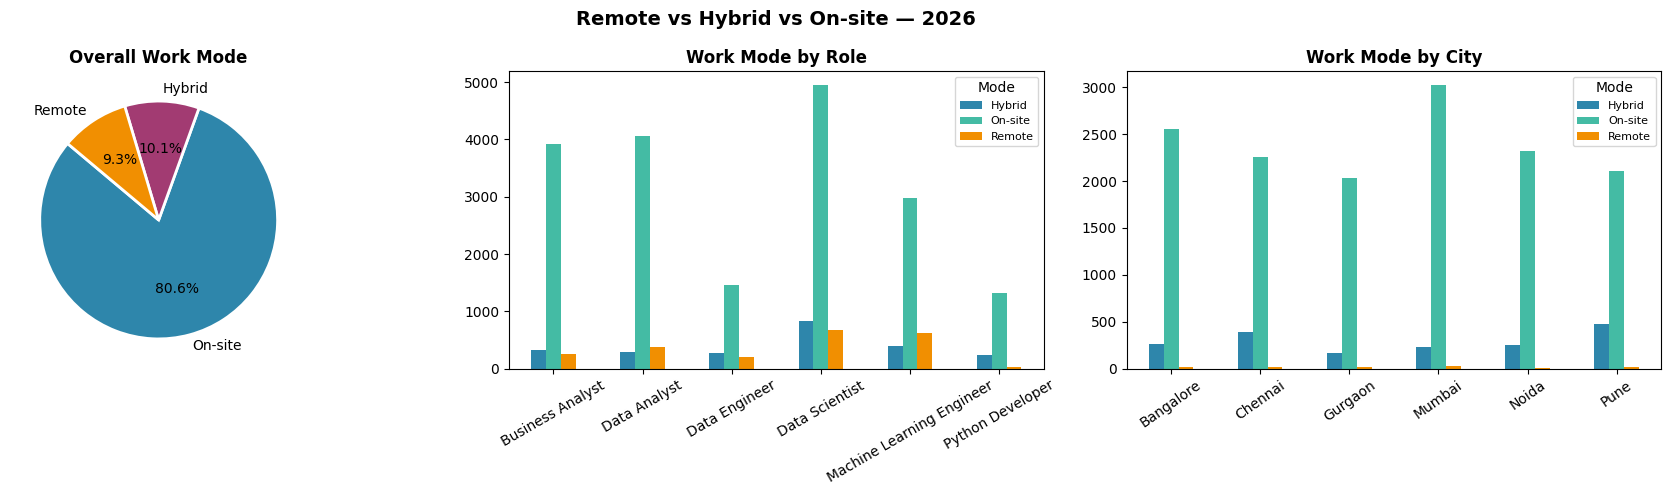

In [11]:
fig, axes = plt.subplots(1,3, figsize=(18, 5))

work_mode_counts = job_dataset['work_mode'].value_counts()

# pie

axes[0].pie(work_mode_counts.values, labels= work_mode_counts.index, 
            autopct='%1.1f%%', colors=PALETTE[:6], startangle=140,wedgeprops={'edgecolor':'white','lw':2})
axes[0].set_title('Overall Work Mode', fontsize=12, fontweight='bold')

# By role
wm_role = job_dataset.groupby(['role_category', 'work_mode']).size().unstack(fill_value=0)

wm_role.plot(kind='bar', ax=axes[1], color=['#2E86AB','#44BBA4','#F18F01'])
axes[1].set_title('Work Mode by Role', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Mode', fontsize=8)

# By top 6 cities

top6 = job_dataset['primary_city'].value_counts().head(6).index

wm_city = (job_dataset[job_dataset['primary_city'].isin(top6)].groupby(['primary_city','work_mode']).size().unstack(fill_value=0))
wm_city.plot(kind='bar', ax=axes[2], color=['#2E86AB','#44BBA4','#F18F01'])

axes[2].set_title('Work Mode by City', fontsize=12, fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=35)
axes[2].legend(title='Mode', fontsize=8)

plt.suptitle('Remote vs Hybrid vs On-site — 2026', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_work_mode.png', bbox_inches='tight')
plt.show()
                            

Insight: 80.6% On-site | 9.3% Remote | 10.1% Hybrid

### 2.4 — Salary Analysis

In [12]:
sal_df = job_dataset[job_dataset['salary_disclosed'] == True].copy()

sal_df = sal_df[sal_df['salary_midpoint_lpa'].between(1, 80)]  # remove outliers

print(f"Salary disclosed: {len(sal_df):,} jobs ({len(sal_df)/len(job_dataset)*100:.1f}%)")
print(f"Salary range    : ₹{sal_df['salary_midpoint_lpa'].min():.1f} – ₹{sal_df['salary_midpoint_lpa'].max():.1f} LPA")
print(f"Median salary   : ₹{sal_df['salary_midpoint_lpa'].median():.1f} LPA")
print(f"Mean salary     : ₹{sal_df['salary_midpoint_lpa'].mean():.1f} LPA")

Salary disclosed: 2,660 jobs (11.5%)
Salary range    : ₹1.1 – ₹80.0 LPA
Median salary   : ₹14.0 LPA
Mean salary     : ₹15.8 LPA


Salary is only disclosed for ~12% of listings. Let's analyze those.

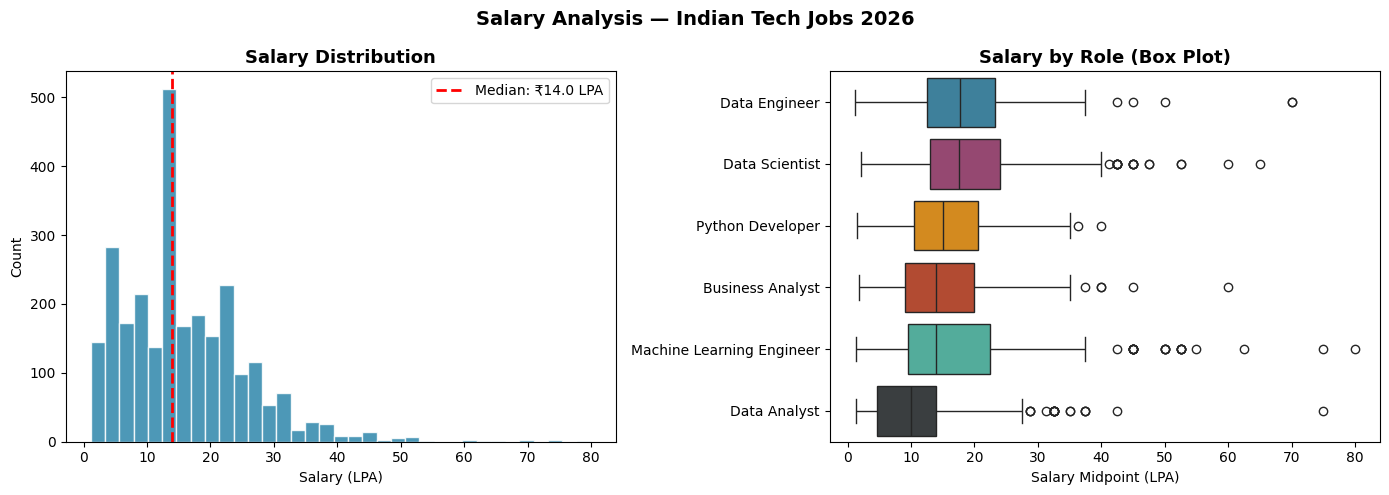

In [13]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# Histogram

axes[0].hist(sal_df['salary_midpoint_lpa'], bins=35, color='#2E86AB',
             edgecolor='white', alpha=0.85)
med = sal_df['salary_midpoint_lpa'].median()
axes[0].axvline(med, color='red', linestyle='--', lw=2,
                label=f'Median: ₹{med:.1f} LPA')
axes[0].set_title('Salary Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salary (LPA)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot by role
order = (sal_df.groupby('role_category')['salary_midpoint_lpa']
               .median().sort_values(ascending=False).index)
sns.boxplot(data=sal_df, x='salary_midpoint_lpa', y='role_category',
            order=order, palette=PALETTE[:6], ax=axes[1])
axes[1].set_title('Salary by Role (Box Plot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Salary Midpoint (LPA)')
axes[1].set_ylabel('')

plt.suptitle('Salary Analysis — Indian Tech Jobs 2026', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_salary_analysis.png', bbox_inches='tight')
plt.show()

Insight: MLE and Data Scientists earn the highest median salaries.

### 2.5 — Experience vs Salary

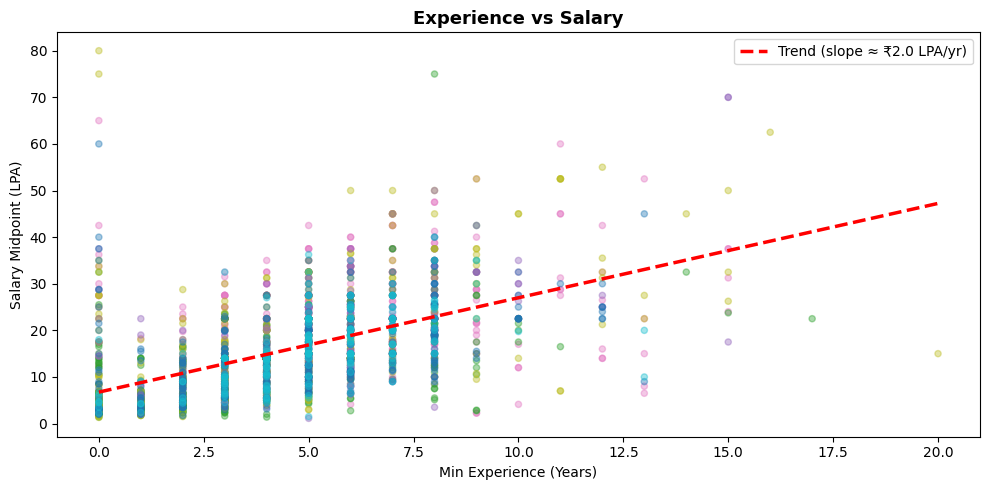

In [14]:
fig, ax = plt.subplots(figsize=(10,5))

plot_df = sal_df.dropna(subset=['experience_min_yrs'])

ax.scatter(plot_df['experience_min_yrs'], plot_df['salary_midpoint_lpa'],
           c=pd.Categorical(plot_df['role_category']).codes,
           alpha=0.4, s=20, cmap='tab10')

# Trend line (linear regression)

z = np.polyfit(plot_df['experience_min_yrs'], plot_df['salary_midpoint_lpa'], 1)

p = np.poly1d(z)

x_range = np.linspace(0, plot_df['experience_min_yrs'].max(), 100)
ax.plot(x_range, p(x_range), 'r--', lw=2.5, label=f'Trend (slope ≈ ₹{z[0]:.1f} LPA/yr)')

ax.set_title('Experience vs Salary', fontsize=13, fontweight='bold')
ax.set_xlabel('Min Experience (Years)')
ax.set_ylabel('Salary Midpoint (LPA)')
ax.legend()
plt.tight_layout()
plt.savefig('05_exp_vs_salary.png', bbox_inches='tight')
plt.show()


Each extra year of experience adds ~₹2.0 LPA on average.

### 2.6 — Skill Domain & Salary Tier

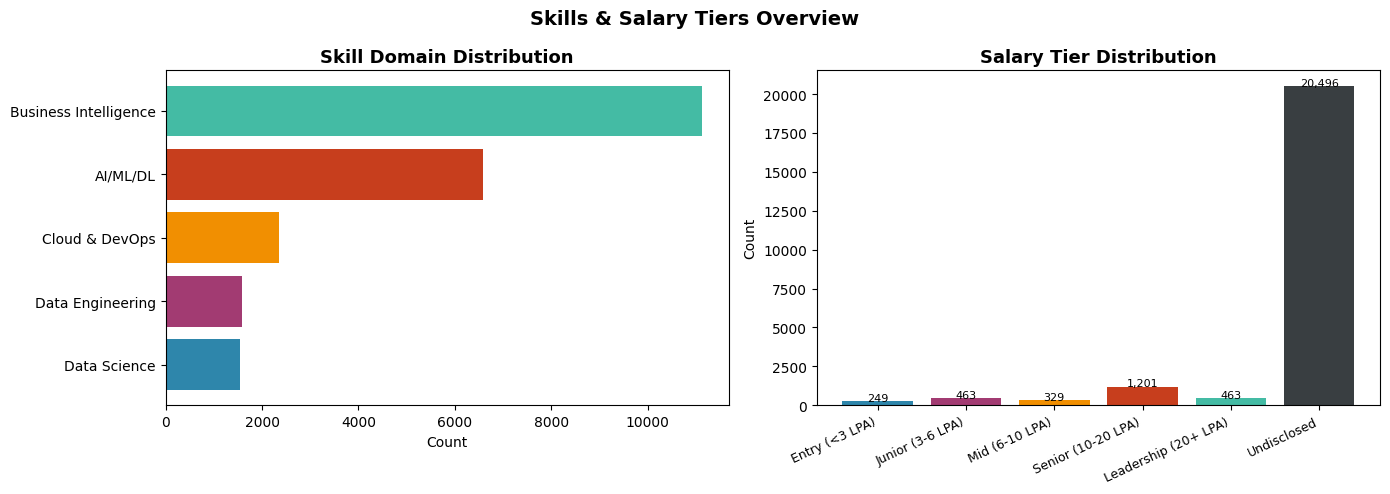

In [15]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sd = job_dataset['skill_domain'].value_counts()

axes[0].barh(sd.index[::-1], sd.values[::-1], color=PALETTE[:len(sd)])

axes[0].set_title('Skill Domain Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

st_order = ['Entry (<3 LPA)','Junior (3-6 LPA)','Mid (6-10 LPA)',
            'Senior (10-20 LPA)','Leadership (20+ LPA)','Undisclosed']

st = job_dataset['salary_tier'].value_counts()

st = st.reindex([s for s in st_order if s in st.index])
bars = axes[1].bar(range(len(st)), st.values, color=PALETTE[:len(st)])
axes[1].set_xticks(range(len(st)))
axes[1].set_xticklabels(st.index, rotation=25, ha='right', fontsize=9)
axes[1].set_title('Salary Tier Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f'{int(bar.get_height()):,}', ha='center', fontsize=8)

plt.suptitle('Skills & Salary Tiers Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_skills_salary_tier.png', bbox_inches='tight')
plt.show()

### 2.7 — Correlation Heatmap

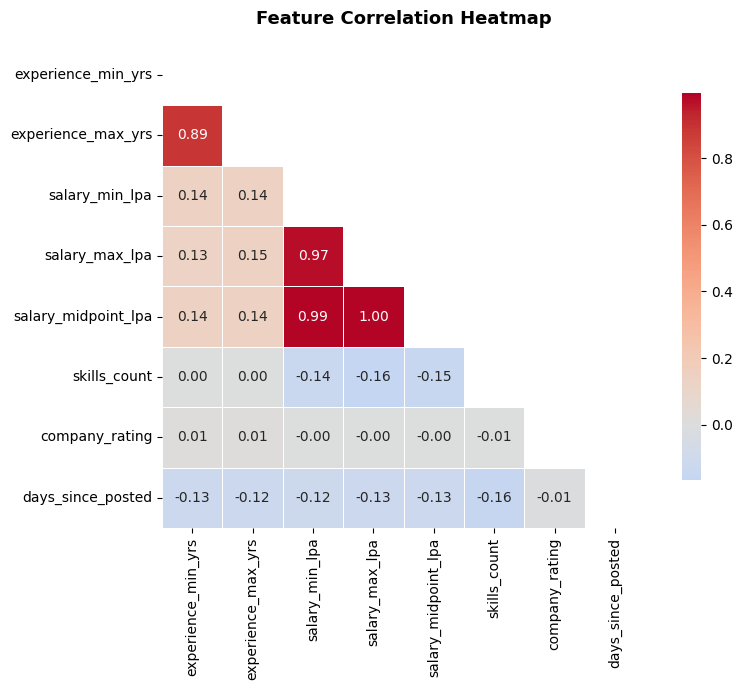

In [16]:
num_cols = ['experience_min_yrs','experience_max_yrs','salary_min_lpa',
            'salary_max_lpa','salary_midpoint_lpa','skills_count',
            'company_rating','days_since_posted']

# Correlation matrix: values close to 1 = strong positive relation
# values close to -1 = strong negative relation
corr = job_dataset[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (duplicate)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5,
            cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('07_correlation.png', bbox_inches='tight')
plt.show()

salary_min & salary_max are highly correlated (expected).

experience_min shows moderate positive correlation with salary.



## Section 3 — Data Preprocessing

Before feeding data into a model, we must:

1. Select features — which columns to use as inputs
2. Encode categories — convert text (e.g. "Bangalore") → numbers
3. Scale numbers — bring all numbers to a similar range
4. Split data — 80% for training, 20% for testing

In [17]:
!pip install scikit-learn

In [18]:
# ── Define features for TASK 1 (Work Mode Classifier) ────────

# These are the INPUT features (what the model sees)
FEATURES_CLF = [
    'role_category',        # Data Scientist, MLE, etc.
    'primary_city',         # Bangalore, Mumbai, etc.
    'experience_min_yrs',   # minimum years of experience
    'experience_max_yrs',   # maximum years of experience
    'skills_count',         # how many skills are listed
    'company_rating',       # company rating out of 5
    'company_size_bucket',  # Large / Mid / Small
    'skill_domain',         # AI/ML/DL, BI, Cloud, etc.
    'is_senior',            # 1 if senior role, 0 otherwise
    'is_fresher_friendly',  # 1 if freshers can apply
    'days_since_posted',    # how recently was it posted
]
TARGET_CLF = 'work_mode'   # OUTPUT we want to predict

# Prepare the data
clf_df = job_dataset[FEATURES_CLF + [TARGET_CLF]].copy()
clf_df['is_senior']           = clf_df['is_senior'].astype(int)  # bool → 1/0
clf_df['is_fresher_friendly'] = clf_df['is_fresher_friendly'].astype(int)

print(f"✅ Features selected: {len(FEATURES_CLF)}")
print(f"   Dataset size: {len(clf_df):,} rows")
print(f"\nTarget class distribution:")
print(clf_df[TARGET_CLF].value_counts())

✅ Features selected: 11
   Dataset size: 23,201 rows

Target class distribution:
work_mode
On-site    18701
Hybrid      2347
Remote      2153
Name: count, dtype: int64


In [20]:
# ── Identify numeric vs categorical columns ───────────────────

# Numeric features: already numbers — just fill missing + scale
num_features_clf = ['experience_min_yrs','experience_max_yrs','skills_count',
                    'company_rating','is_senior','is_fresher_friendly','days_since_posted']

# Categorical features: text labels — need to convert to numbers
cat_features_clf = ['role_category','primary_city','company_size_bucket','skill_domain']

# ── Build Preprocessing Pipeline ──────────────────────────────
# Pipeline automatically applies steps in order
preprocessor_clf = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),   # fill missing with median
        ('scaler',  StandardScaler()),                   # scale to mean=0, std=1
    ]), num_features_clf),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),        # fill missing
        ('ohe',     OneHotEncoder(handle_unknown='ignore',           # text → 0/1 columns
                                  sparse_output=False)),
    ]), cat_features_clf),
])

# ── Encode target labels ───────────────────────────────────────
# LabelEncoder converts: 'Remote'→0, 'Hybrid'→1, 'On-site'→2
le_wm = LabelEncoder()
y_clf = le_wm.fit_transform(clf_df[TARGET_CLF])
X_clf = clf_df.drop(columns=[TARGET_CLF])

print(f"Target classes: {dict(enumerate(le_wm.classes_))}")

# ── Train / Test Split ─────────────────────────────────────────
# 80% for training the model, 20% for testing (held out, never seen)
# stratify=y ensures same class ratio in both splits
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"\n✅ Train set: {len(X_train_clf):,} rows")
print(f"   Test set : {len(X_test_clf):,} rows")

NameError: name 'ColumnTransformer' is not defined

## Section 4 — ML Task 1: Work Mode Classifier